# VGGT sampling-strategy ablation on a VSI-Bench video

For one VSI-Bench scene (raw mp4, decoded via decord — no ScanNet depth/pose files needed here), compares 3 ways of picking 8 frames for VGGT:

1. **fps** — the existing production method (`dataset/extract_vsibench_frames.py`'s farthest-point-sampling over a candidate pool), imported directly, not reimplemented
2. **random** — uniform random choice of 8 frame indices
3. **uniform** — evenly-spaced indices across the whole clip

Each produces an 8-frame VGGT point cloud. Reference/"pseudo-GT" is a VGGT reconstruction from a larger, uniformly-spread frame sample (`GT_MAX_FRAMES`, capped — see next cell) of the *same* video. No real depth/pose ground truth is used; this only tests self-consistency (does an 8-frame reconstruction agree with a many-frame reconstruction of the same scene), not absolute geometric accuracy.

Comparison: VGGT's own coordinate frame is arbitrary per run (different frame subsets → different up-to-scale, different origin), so the two point clouds aren't in the same frame by default. Align via correspondence-free ICP+scale (implemented below with scipy's cKDTree — no ground-truth loader needed, no ScanNet-specific code), then report the post-alignment mean nearest-neighbor distance as the disagreement score.

**CPU memory/speed warning**: VGGT's aggregator does joint cross-frame attention over the *entire* input sequence at once — cost scales with frame count, not linearly-friendly. `GT_MAX_FRAMES` frames in one forward pass on CPU can be slow and/or OOM well before you'd expect from "just more images". Default is capped (not literally "most of the scene") for this reason — see the config cell for how to size it up if you have a GPU.

In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
VGGT_ROOT = ROOT / "vggt"
for p in (ROOT, VGGT_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import torch
from PIL import Image
from scipy.spatial import cKDTree
from decord import VideoReader, cpu as decord_cpu

from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri

# reuse the existing production FPS sampler as-is, don't reimplement it
from dataset.extract_vsibench_frames import _sample_frame_indices_fps

print("root:", ROOT)

root: /glob/g01-cache/pf/Yushuo/vjepa201


In [10]:
# ── config — edit this ──────────────────────────────────────────────────────
VSI_DIR = ROOT / "source_data/vsibench"
DATASET = "scannet"
SCENE_NAME = "scene0011_00"           # matches source_data/vsibench/scannet/{SCENE_NAME}.mp4
VIDEO_PATH = VSI_DIR / DATASET / f"{SCENE_NAME}.mp4"

S_INPUT = 8                # frames per sampling method under test
POOL_SIZE = 64              # FPS candidate pool size, matches extract_vsibench_frames.py default

# "pseudo-GT" reconstruction: uniformly-spread frames across the whole clip.
# NOT "most of the scene" — capped, see CPU warning below. Bump this up freely on GPU.
GT_MAX_FRAMES = 24

CONF_THRES = 5.0
VGGT_CKPT = ROOT / "ckpts/vggt.pt"
OUTPUT_DIR = ROOT / "outputs/vggt_vsibench_sampling_ablation"
TMP_FRAMES_DIR = OUTPUT_DIR / "tmp_frames"
SEED = 0

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TMP_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if device.type == "cuda" and torch.cuda.get_device_capability()[0] >= 8 else torch.float16
print("device:", device, "dtype:", dtype)

if device.type == "cpu" and GT_MAX_FRAMES > 16:
    print(f"WARNING: device=cpu and GT_MAX_FRAMES={GT_MAX_FRAMES}. VGGT's aggregator does joint "
          f"cross-frame attention over all {GT_MAX_FRAMES} frames at once in a single forward pass — "
          f"this is not like decoding frames one at a time, memory/time grows fast with frame count. "
          f"If this hangs or OOMs, lower GT_MAX_FRAMES (try 8-12) or run on a GPU node instead.")

device: cpu dtype: torch.float16


## Helpers

Sampling: `uniform`/`random` are one-liners; `fps` calls the real production function (`_sample_frame_indices_fps`) from `dataset/extract_vsibench_frames.py` so this notebook can't silently drift from what actually ships.

Alignment: `icp_with_scale` is a from-scratch point-to-point ICP with a scale DOF (nearest-neighbor correspondence each iteration via `cKDTree`, then closed-form similarity fit — same `umeyama`-style math as the other notebook, just without known correspondences, so it has to alternate "find nearest neighbor" / "re-fit transform" until it converges). `coarse_align` gives it a sane starting point (centroid + bbox-scale match) since ICP without a decent initial guess can lock onto a wrong local minimum.

In [3]:
# ── frame-index sampling strategies ───────────────────────────────────────────
def sample_uniform_indices(total: int, n: int) -> list[int]:
    if n >= total:
        return list(range(total))
    if n == 1:
        return [total // 2]
    return [round(i * (total - 1) / (n - 1)) for i in range(n)]


def sample_random_indices(total: int, n: int, seed: int) -> list[int]:
    rng = np.random.default_rng(seed)
    return sorted(rng.choice(total, size=min(n, total), replace=False).tolist())


def sample_fps_indices(vr: VideoReader, total: int, n: int, pool_size: int) -> list[int]:
    return _sample_frame_indices_fps(total, n, pool_size, vr)


# ── decode selected frames to temp jpgs (VGGT's loader wants file paths) ─────
def decode_frames_to_tmp(vr: VideoReader, indices: list[int], tag: str) -> list[str]:
    frames = vr.get_batch(indices).asnumpy()  # (len(indices), H, W, C) uint8
    out_dir = TMP_FRAMES_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for k, frame in enumerate(frames):
        p = out_dir / f"frame_{k:03d}.jpg"
        Image.fromarray(frame).save(p, quality=95)
        paths.append(str(p))
    return paths


@torch.no_grad()
def run_vggt(model: VGGT, image_paths: list[str]) -> dict:
    images = load_and_preprocess_images(image_paths).to(device)  # (S, 3, H, W)
    with torch.autocast(device_type=device.type, dtype=dtype, enabled=device.type == "cuda"):
        predictions = model(images)
    extrinsic, intrinsic = pose_encoding_to_extri_intri(predictions["pose_enc"], images.shape[-2:])
    predictions["extrinsic"] = extrinsic
    predictions["intrinsic"] = intrinsic
    return {k: (v.squeeze(0).float().cpu().numpy() if isinstance(v, torch.Tensor) else v)
            for k, v in predictions.items()}


def extract_pointcloud(preds: dict, conf_thres: float):
    """(S,H,W,3) world_points + (S,H,W) world_points_conf + (S,3,H,W) images -> (pts, colors_uint8)."""
    pts = preds["world_points"]
    conf = preds["world_points_conf"]
    imgs = preds["images"]
    mask = conf > conf_thres
    verts = pts[mask]
    colors = (imgs.transpose(0, 2, 3, 1)[mask] * 255).astype(np.uint8)
    return verts, colors


def save_pointcloud_ply(pts: np.ndarray, colors: np.ndarray, out_path: Path) -> None:
    import trimesh
    out_path.parent.mkdir(parents=True, exist_ok=True)
    trimesh.PointCloud(pts, colors=colors).export(str(out_path))


# ── correspondence-free similarity alignment (coarse init + ICP w/ scale) ────
def coarse_align(src: np.ndarray, dst: np.ndarray) -> np.ndarray:
    src_c, dst_c = src - src.mean(0), dst - dst.mean(0)
    scale = np.linalg.norm(dst_c, axis=1).std() / max(np.linalg.norm(src_c, axis=1).std(), 1e-8)
    return src_c * scale + dst.mean(0)


def umeyama_alignment(src: np.ndarray, dst: np.ndarray, with_scale: bool = True):
    """Closed-form similarity transform (R, t, s) minimizing ||s*R@src + t - dst||^2 for MATCHED pairs."""
    n = src.shape[0]
    mu_src, mu_dst = src.mean(axis=0), dst.mean(axis=0)
    src_c, dst_c = src - mu_src, dst - mu_dst
    cov = (dst_c.T @ src_c) / n
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[2, 2] = -1
    R = U @ S @ Vt
    if with_scale:
        var_src = (src_c ** 2).sum() / n
        s = np.trace(np.diag(D) @ S) / var_src
    else:
        s = 1.0
    t = mu_dst - s * R @ mu_src
    return R, t, s


def icp_with_scale(src: np.ndarray, dst: np.ndarray, max_iters: int = 50, tol: float = 1e-6,
                    max_dst_points: int = 50000, max_src_points: int = 20000):
    """Point-to-point ICP with a scale DOF, no known correspondences.

    Each iteration: nearest-neighbor match against dst (via cKDTree), fit a similarity
    transform (Umeyama) to those matched pairs, apply it, repeat until the mean
    nearest-neighbor distance stops improving.

    Returns (aligned_src, mean_nn_dist, src_idx) — src_idx is which rows of the
    ORIGINAL src were kept (src gets subsampled to max_src_points for speed), so the
    caller can slice a matching colors array as colors[src_idx].
    """
    rng = np.random.default_rng(0)
    dst_sub = dst[rng.choice(len(dst), max_dst_points, replace=False)] if len(dst) > max_dst_points else dst
    src_idx = rng.choice(len(src), max_src_points, replace=False) if len(src) > max_src_points else np.arange(len(src))
    cur = src[src_idx].copy()

    tree = cKDTree(dst_sub)
    prev_err = np.inf
    for _ in range(max_iters):
        dists, idxs = tree.query(cur)
        matched = dst_sub[idxs]
        R, t, s = umeyama_alignment(cur, matched, with_scale=True)
        cur = (s * (R @ cur.T).T) + t
        err = float(dists.mean())
        if abs(prev_err - err) < tol:
            break
        prev_err = err
    return cur, err, src_idx

## Load VGGT (once) + open the video

In [4]:
print(f"loading VGGT from {VGGT_CKPT} ...")
model = VGGT()
state = torch.load(VGGT_CKPT, map_location="cpu", weights_only=True)
model.load_state_dict(state)
model.eval().to(device)
print("loaded.")

vr = VideoReader(str(VIDEO_PATH), ctx=decord_cpu(0))
total_frames = len(vr)
print(f"video: {VIDEO_PATH}")
print(f"total frames: {total_frames}")

loading VGGT from /glob/g01-cache/pf/Yushuo/vjepa201/ckpts/vggt.pt ...
loaded.
video: /glob/g01-cache/pf/Yushuo/vjepa201/source_data/vsibench/scannet/scene0011_00.mp4
total frames: 2374


## Build the pseudo-GT reconstruction

Uniformly-spread `GT_MAX_FRAMES` frames across the whole clip, one VGGT forward pass. This is the single most memory/time-heavy cell in the notebook — see the CPU warning in the config cell if it hangs.

In [5]:
gt_n = min(GT_MAX_FRAMES, total_frames)
gt_indices = sample_uniform_indices(total_frames, gt_n)
print(f"pseudo-GT: {gt_n} frames, indices {gt_indices[:5]}...{gt_indices[-5:]}")

gt_paths = decode_frames_to_tmp(vr, gt_indices, "gt")
gt_preds = run_vggt(model, gt_paths)
gt_pts, gt_colors = extract_pointcloud(gt_preds, CONF_THRES)
print(f"pseudo-GT point cloud: {len(gt_pts)} points")

save_pointcloud_ply(gt_pts, gt_colors, OUTPUT_DIR / SCENE_NAME / "gt.ply")

pseudo-GT: 24 frames, indices [0, 103, 206, 310, 413]...[1960, 2063, 2167, 2270, 2373]
pseudo-GT point cloud: 849690 points


## Compare: fps / random / uniform, each 8 frames, aligned against pseudo-GT

In [7]:
CONF_THRES = 3.0
sampler_fns = {
    "fps": lambda: sample_fps_indices(vr, total_frames, S_INPUT, POOL_SIZE),
    "random": lambda: sample_random_indices(total_frames, S_INPUT, SEED),
    "uniform": lambda: sample_uniform_indices(total_frames, S_INPUT),
}

results = []
clouds = {"gt": (gt_pts, gt_colors)}

for method, sampler in sampler_fns.items():
    indices = sampler()
    print(f"\n=== {method}: indices={indices} ===")

    paths = decode_frames_to_tmp(vr, indices, method)
    preds = run_vggt(model, paths)
    pts, colors = extract_pointcloud(preds, CONF_THRES)

    coarse_pts = coarse_align(pts, gt_pts)
    aligned_pts, mean_nn_dist, src_idx = icp_with_scale(coarse_pts, gt_pts)

    save_pointcloud_ply(pts, colors, OUTPUT_DIR / SCENE_NAME / f"{method}.ply")
    clouds[method] = (aligned_pts, colors[src_idx])   # colors sliced with the SAME subsample ICP used

    results.append({
        "method": method,
        "indices": indices,
        "n_points_raw": len(pts),
        "mean_nn_dist_after_icp": mean_nn_dist,
    })
    print(f"{method}: n_points={len(pts)} mean_nn_dist_after_icp={mean_nn_dist:.4f}")

df = pd.DataFrame(results)
df.to_csv(OUTPUT_DIR / SCENE_NAME / "metrics.csv", index=False)
df


=== fps: indices=[0, 263, 1205, 1280, 1770, 2109, 2147, 2184] ===
fps: n_points=10481 mean_nn_dist_after_icp=0.0073

=== random: indices=[39, 97, 178, 639, 729, 1210, 1508, 2013] ===
random: n_points=711901 mean_nn_dist_after_icp=0.0168

=== uniform: indices=[0, 339, 678, 1017, 1356, 1695, 2034, 2373] ===
uniform: n_points=727189 mean_nn_dist_after_icp=0.0274


,method,indices,n_points_raw,mean_nn_dist_after_icp
0,fps,"[0, 263, 1205, 1280, 1770, 2109, 2147, 2184]",10481,0.007315
1,random,"[39, 97, 178, 639, 729, 1210, 1508, 2013]",711901,0.016797
2,uniform,"[0, 339, 678, 1017, 1356, 1695, 2034, 2373]",727189,0.027384


## Visualize: GT + 3 methods (all aligned into GT's frame)

Unlike the ScanNet notebook, these 4 panels ARE in the same coordinate frame (ICP put them there), so overlay/side-by-side both make sense here.

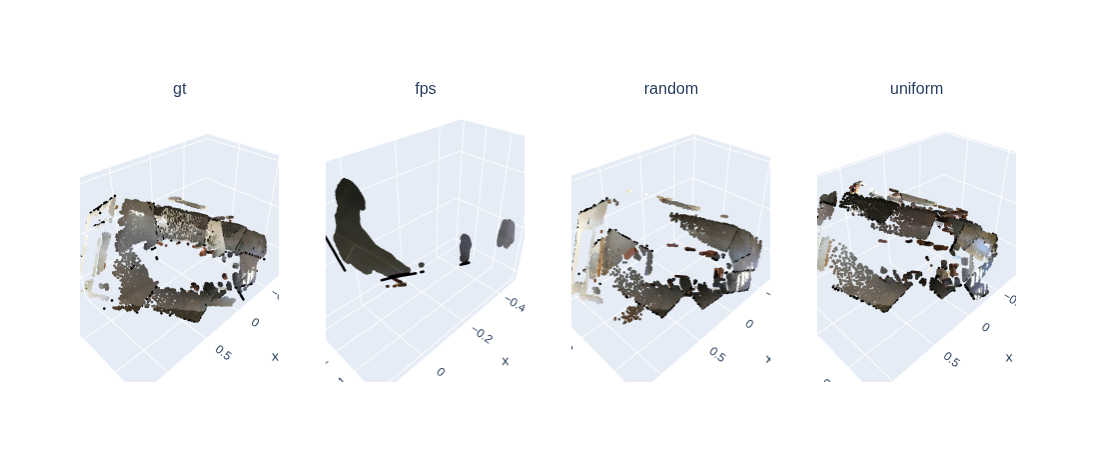

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def scatter3d(pts, colors, name, max_points=30000):
    if len(pts) > max_points:
        idx = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts, colors = pts[idx], colors[idx]
    return go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="markers", name=name,
        marker=dict(size=1.5, color=[f"rgb({r},{g},{b})" for r, g, b in colors]),
    )


panel_order = ["gt", "fps", "random", "uniform"]
fig = make_subplots(rows=1, cols=4, specs=[[{"type": "scene"}] * 4], subplot_titles=panel_order)
for col, name in enumerate(panel_order, start=1):
    pts, colors = clouds[name]
    fig.add_trace(scatter3d(pts, colors, name), row=1, col=col)

fig.update_layout(
    height=450, width=1800, showlegend=False,
    **{f"scene{i if i > 1 else ''}": dict(aspectmode="data") for i in range(1, 5)},
)
fig.show()

### Real GT from SCANNET

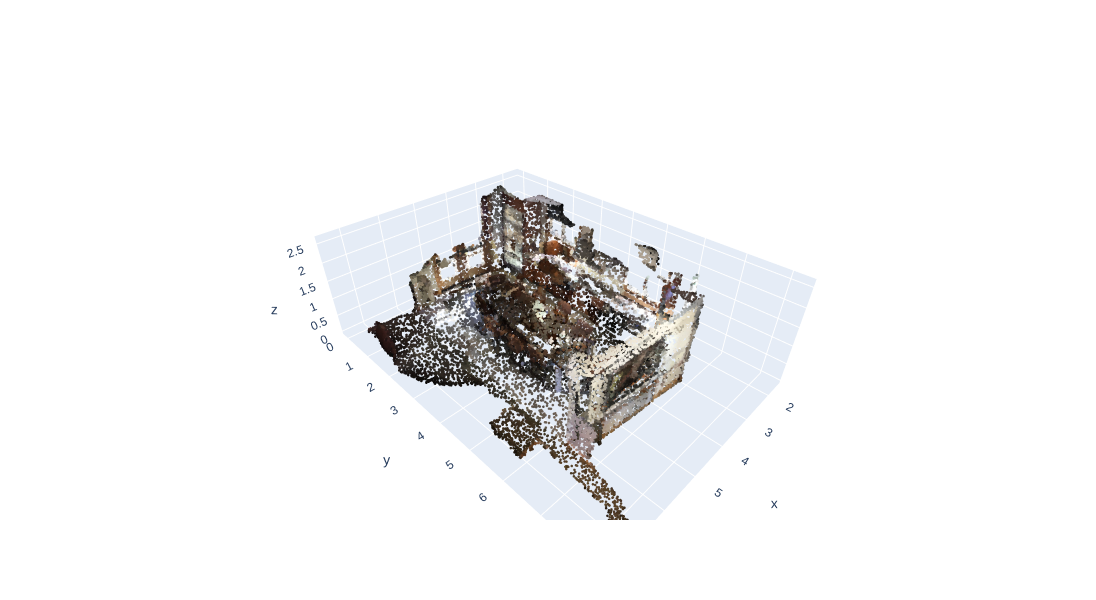

In [16]:
## visualize the ori ply of the scnene

mesh_root = ROOT / "source_data/scannet_mesh/scans" / SCENE_NAME
ply_candidates = list(mesh_root.rglob("*_vh_clean_2.ply"))
if not ply_candidates:
  raise FileNotFoundError(f"no *_vh_clean_2.ply under {mesh_root}")
mesh_path = ply_candidates[0]
def read_ply_vertices(path):
  type_map = {
      "float": "f4", "float32": "f4", "double": "f8", "float64": "f8",
      "uchar": "u1", "uint8": "u1", "char": "i1", "int8": "i1",
      "short": "i2", "int16": "i2", "ushort": "u2", "uint16": "u2",
      "int": "i4", "int32": "i4", "uint": "u4", "uint32": "u4",
  }
  with open(path, "rb") as f:
      assert f.readline().decode("ascii").strip() == "ply"
      fmt, n_vertices, properties, in_vertex = None, 0, [], False
      while True:
          line = f.readline().decode("ascii").strip()
          if line.startswith("format"):
              fmt = line.split()[1]
          elif line.startswith("element vertex"):
              n_vertices = int(line.split()[-1])
              in_vertex = True
          elif line.startswith("element"):
              in_vertex = False
          elif line.startswith("property") and in_vertex:
              _, ptype, pname = line.split()
              properties.append((pname, ptype))
          elif line == "end_header":
              break
      dtype = np.dtype([(name, type_map[t]) for name, t in properties])
      if fmt == "ascii":
          data = np.loadtxt(f, dtype=dtype, max_rows=n_vertices)
      else:
          dtype = dtype.newbyteorder("<" if fmt == "binary_little_endian" else ">")
          data = np.fromfile(f, dtype=dtype, count=n_vertices)
  pts = np.stack([data["x"], data["y"], data["z"]], axis=-1).astype(np.float64)
  colors = np.stack([data["red"], data["green"], data["blue"]], axis=-1).astype(np.uint8) \
      if "red" in data.dtype.names else np.full((len(pts), 3), 128, dtype=np.uint8)
  return pts, colors

pts, colors = read_ply_vertices(mesh_path)

fig = go.Figure(data=[scatter3d(pts, colors, "gt_mesh")])
fig.update_layout(height=600, width=700, showlegend=False, scene=dict(aspectmode="data"))
fig.show()

### Cal the Dist from Real GT

In [17]:
gt_mesh_pts, gt_mesh_colors = pts, colors   # from the mesh-loading cell above

results = []
for method in ["fps", "random", "uniform", "gt"]:
  src_pts, _ = clouds[method]
  coarse = coarse_align(src_pts, gt_mesh_pts)
  aligned, mean_nn_dist, _ = icp_with_scale(coarse, gt_mesh_pts)
  results.append({"method": method, "mean_nn_dist_vs_gt_mesh": mean_nn_dist})
  print(f"{method}: mean_nn_dist_vs_gt_mesh={mean_nn_dist:.4f}")

gt_scale = float(np.linalg.norm(gt_mesh_pts.max(0) - gt_mesh_pts.min(0)))
df_gt = pd.DataFrame(results)
df_gt["relative"] = df_gt["mean_nn_dist_vs_gt_mesh"] / gt_scale
print(f"\ngt_scale (bbox diagonal) = {gt_scale:.4f}")
df_gt

fps: mean_nn_dist_vs_gt_mesh=0.0680
random: mean_nn_dist_vs_gt_mesh=0.1376
uniform: mean_nn_dist_vs_gt_mesh=0.1111
gt: mean_nn_dist_vs_gt_mesh=0.1411

gt_scale (bbox diagonal) = 10.4392


,method,mean_nn_dist_vs_gt_mesh,relative
0,fps,0.067955,0.006510
1,random,0.137585,0.013180
2,uniform,0.111136,0.010646
3,gt,0.141146,0.013521
